<a href="https://colab.research.google.com/github/mahmudjan2006/CW2/blob/main/00017683%2C_00019810_CW_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Final Project: Student Success Copilot

**Goal:** A hybrid AI assistant designed to help students optimize their study schedules, predict academic workloads, and identify risk factors early using expert logic and search algorithms.

### 🏗️ System Architecture & Technologies
- **Natural Language Processing (NLP):** Flexible input handling for task difficulty (e.g., 'tough', 'simple') and relative deadlines (e.g., 'in 2 days').
- **Machine Learning (ML):** A Linear Regression model trained on student data to predict the specific study hours required based on stress levels, attendance, and quiz scores.
- **Expert System (Rule Engine):**
    - **Forward Chaining:** To dynamically determine risk levels (Low/Medium/High) based on existing profile facts.
    - **Backward Chaining:** To identify missing information and ask the user smart, context-aware questions.
- **Search Algorithms:**
    - **A* Search:** Used for optimal, constraint-satisfying schedule generation (balancing streaks and breaks).
    - **Greedy Search:** Used for fast, best-effort scheduling when deadlines are tight.
    - **Force Mode:** An emergency planning mode that eliminates non-essential breaks to meet impossible deadlines.

---

### 🚀 How to Use
1. **Run All Cells**: Ensure the ML model is trained and core classes are initialized.
2. **Execute Interactive Mode**: Run the cell below.
3. **Provide Profile**: Enter your current academic stats (attendance, scores, etc.).
4. **Define Tasks**: List your upcoming assignments using natural language for dates and difficulty.
5. **Review Report**: The system will output a Risk Assessment, Predicted Hours, and a detailed Hour-by-Hour study plan.

# 📑 SECTION 1: CORE INFRASTRUCTURE & NLP CONFIGURATION
This cell initializes the rule-based expert system, the search-based planning algorithms, and natural language processing constants for flexible user input.

In [ ]:
# Pre-requisites and setup
import os
os.makedirs('ml', exist_ok=True)
os.makedirs('planner', exist_ok=True)

In [ ]:
import pandas as pd
import datetime
import time as time_lib
import sys
import heapq
import joblib
import numpy as np
import os
import re
from datetime import time, timedelta
from dataclasses import dataclass
from typing import Any

# --- NLP CONSTANTS ---
DIFFICULTY_KEYWORDS = {
    'hard': ['hard', 'difficult', 'tough', 'complex', 'challenging', 'heavy'],
    'easy': ['easy', 'simple', 'light', 'quick', 'short', 'trivial'],
    'medium': ['medium', 'moderate', 'average', 'normal', 'okay', 'ok']
}

DAY_ALIASES = {
    'mon': 'Monday', 'monday': 'Monday',
    'tue': 'Tuesday', 'tues': 'Tuesday', 'tuesday': 'Tuesday',
    'wed': 'Wednesday', 'weds': 'Wednesday', 'wednesday': 'Wednesday',
    'thu': 'Thursday', 'thur': 'Thursday', 'thurs': 'Thursday', 'thursday': 'Thursday',
    'fri': 'Friday', 'friday': 'Friday',
    'sat': 'Saturday', 'saturday': 'Saturday',
    'sun': 'Sunday', 'sunday': 'Sunday'
}

# --- CORE COMPONENT: Student Planner ---
class ScheduleState:
    def __init__(self, current_day_idx, current_hour, workload, schedule, streak, total_hours_elapsed):
        self.day_idx = current_day_idx; self.hour = current_hour; self.workload = workload
        self.schedule = schedule; self.streak = streak; self.g = total_hours_elapsed
    def is_goal(self): return sum(self.workload.values()) == 0
    def __lt__(self, other): return self.g < other.g

class StudentPlanner:
    def __init__(self, name):
        self.name = name; self.tasks = []; self.force_mode = False
        self.days = [datetime.date.today() + timedelta(days=i) for i in range(7)]

    def add_task(self, name, credits, hours, deadline_input):
        deadline_date = None
        # NLP: relative dates
        match = re.search(r'in (\d+) days?', deadline_input.lower())
        if match:
            offset = int(match.group(1))
            deadline_date = datetime.date.today() + timedelta(days=offset)
        else:
            # NLP: day name matching
            clean_input = deadline_input.lower().strip()
            target_day = next((full for alias, full in DAY_ALIASES.items() if alias in clean_input), None)
            if target_day:
                for d in self.days:
                    if d.strftime('%A') == target_day:
                        deadline_date = d; break

        if not deadline_date:
            deadline_date = self.days[-1] # Fallback

        self.tasks.append({'name': name, 'hours': hours, 'deadline': deadline_date})

    def heuristic(self, state):
        h = 0; current_date = self.days[state.day_idx]
        for task in self.tasks:
            hours_left = state.workload[task['name']]
            if hours_left > 0:
                days_left = (task['deadline'] - current_date).days
                if not self.force_mode and days_left < 0: return float('inf')
                h += (20 / (max(0, days_left) + 0.5)) * hours_left
        return h

    def solve(self, mode='astar'):
        start_time = time_lib.perf_counter()
        initial_workload = {t['name']: t['hours'] for t in self.tasks}
        initial_state = ScheduleState(0, 7, initial_workload, [], 0, 0)
        frontier = []; heapq.heappush(frontier, (self.heuristic(initial_state) if mode=='astar' else 0, initial_state))
        visited_count = 0; best_state = initial_state; limit = 20000
        while frontier:
            f, current = heapq.heappop(frontier); visited_count += 1
            if sum(current.workload.values()) < sum(best_state.workload.values()): best_state = current
            if current.is_goal(): return current.schedule, self._get_stats(current.schedule, time_lib.perf_counter() - start_time)
            next_day, next_hour = (current.day_idx, current.hour + 1) if current.hour < 22 else (current.day_idx + 1, 8)
            if next_day > 6: continue
            time_label = f"{next_hour:02d}:00 - {next_hour+1:02d}:00"; day_name = self.days[next_day].strftime('%A')
            if not self.force_mode and current.streak >= 2:
                heapq.heappush(frontier, (0, ScheduleState(next_day, next_hour, current.workload.copy(), current.schedule + [{'task': 'BREAK', 'day': day_name, 'hour_label': time_label}], 0, current.g + 1)))
                continue
            for t_name, hrs in current.workload.items():
                if hrs > 0:
                    nw = current.workload.copy(); nw[t_name] -= 1
                    ns = ScheduleState(next_day, next_hour, nw, current.schedule + [{'task': t_name, 'day': day_name, 'hour_label': time_label}], current.streak + 1, current.g + 1)
                    heapq.heappush(frontier, (ns.g + self.heuristic(ns) if mode=='astar' else self.heuristic(ns), ns))
            if visited_count > limit: break
        return best_state.schedule, self._get_stats(best_state.schedule, time_lib.perf_counter() - start_time)

    def run_astar(self): return self.solve(mode='astar')
    def run_greedy(self): return self.solve(mode='greedy')
    def _get_stats(self, schedule, duration):
        done = len([s for s in schedule if s['task'] not in ['BREAK', 'FREE', 'BUSY']])
        total = sum(t['hours'] for t in self.tasks)
        return {"Time (ms)": round(duration * 1000, 2), "Completion": f"{(done/total):.1%}"}

In [ ]:
# Core initialization cell - Project structure ready.

In [ ]:
from dataclasses import dataclass, field
from typing import Any

@dataclass
class Fact:
    key: str
    value: Any

@dataclass
class Rule:
    name: str
    conditions: list
    action_key: str
    action_value: Any
    confidence: float
    explanation: str

class RuleEngine:
    def __init__(self):
        self.working_memory: dict = {}
        self.fired_rules: list = []
        self.derived_facts: list = []
        self._define_rules()

    def _define_rules(self):
        self.rules = [
            Rule("RULE-01", [("deadline_days", "<=", 3), ("task_difficulty", "==", "hard")], "priority", "HIGH", 0.9, "Deadline <= 3 days AND hard task"),
            Rule("RULE-02", [("missed_sessions", ">=", 2), ("confidence_level", "<=", 3)], "risk_signal", "ELEVATED", 0.85, "Missed sessions AND low confidence"),
            Rule("RULE-03", [("total_task_hours", ">", "free_hours")], "overload_flag", True, 0.8, "Workload exceeds free hours"),
            Rule("RULE-04", [("stress_level", ">=", 7)], "recommend_breaks", True, 0.75, "High stress detected"),
            Rule("RULE-05", [("confidence_level", "<=", 2)], "recommend_support", True, 0.8, "Very low confidence"),
            Rule("RULE-06", [("priority", "==", "HIGH"), ("overload_flag", "==", True)], "risk_level", "High", 0.95, "High priority AND overloaded"),
            Rule("RULE-07", [("risk_signal", "==", "ELEVATED"), ("stress_level", ">=", 4)], "risk_level", "High", 0.88, "Elevated risk signal AND high stress"),
            Rule("RULE-08", [("attendance_rate", ">=", 80), ("confidence_level", ">=", 7)], "risk_level", "Low", 0.85, "Good attendance AND high confidence"),
            Rule("RULE-09", [("missed_sessions", ">=", 1), ("deadline_days", "<=", 5)], "risk_level", "Medium", 0.7, "Missed sessions near deadline")
        ]

    def _evaluate_condition(self, key, operator, value):
        if key not in self.working_memory: return False
        actual = self.working_memory[key]
        compare_to = self.working_memory[value] if isinstance(value, str) and value in self.working_memory else value
        ops = {"==": lambda a,b: a==b, ">=": lambda a,b: a>=b, "<=": lambda a,b: a<=b, ">": lambda a,b: a>b, "<": lambda a,b: a<b}
        try: return ops[operator](actual, compare_to)
        except: return False

    def forward_chain(self, facts):
        self.working_memory = facts.copy()
        self.fired_rules = []; changed = True
        risk_priority = {"Low": 1, "Medium": 2, "High": 3}

        while changed:
            changed = False
            for rule in self.rules:
                if rule.name in [r['rule'] for r in self.fired_rules]: continue
                if all(self._evaluate_condition(k,op,v) for k,op,v in rule.conditions):
                    new_val = rule.action_value

                    # Special logic for risk_level severity overwriting
                    if rule.action_key == "risk_level":
                        current = self.working_memory.get("risk_level", None)
                        if current is None or risk_priority.get(new_val, 0) > risk_priority.get(current, 0):
                            self.working_memory[rule.action_key] = new_val
                            self.fired_rules.append({'rule': rule.name, 'explanation': rule.explanation})
                            changed = True
                    else:
                        self.working_memory[rule.action_key] = new_val
                        self.fired_rules.append({'rule': rule.name, 'explanation': rule.explanation})
                        changed = True
        return {'risk_level': self.working_memory.get('risk_level', 'Medium'), 'fired_rules': self.fired_rules}

    def backward_chain(self, goal_key):
        missing = []
        for r in [r for r in self.rules if r.action_key == goal_key]:
            for cond_k, _, _ in r.conditions:
                if cond_k not in self.working_memory: missing.append(cond_k)
        return list(set(missing))

# 🤖 SECTION 2: MACHINE LEARNING - REGRESSION ANALYSIS
This section handles the generation of synthetic data and the training of the Linear Regression model to predict academic study requirements.

In [ ]:
import pandas as pd
import numpy as np
import os

def generate_data(n=1000):
    """Generates a synthetic dataset for the Student Success Copilot."""
    np.random.seed(42)
    data = {
        'student_id': range(1, n + 1),
        'gender': np.random.choice(['Male', 'Female'], n, p=[0.5, 0.5]),
        'attendance_rate': np.random.uniform(40, 100, n),
        'avg_quiz_score': np.random.uniform(30, 100, n),
        'confidence_level': np.random.randint(1, 11, n),
        'stress_level': np.random.randint(1, 6, n)
    }
    df = pd.DataFrame(data)
    study_hours_factor = (
        (100 - df['attendance_rate']) * 0.15 +
        (100 - df['avg_quiz_score']) * 0.2 +
        (11 - df['confidence_level']) * 1.5 +
        (df['stress_level'] - 1) * 1.2
    )
    df['weekly_study_hours'] = study_hours_factor + np.random.normal(0, 3, n)
    df['weekly_study_hours'] = df['weekly_study_hours'].clip(lower=2, upper=45).round(1)

    risk_score = ((100 - df['attendance_rate']) * 0.35 + (100 - df['avg_quiz_score']) * 0.35 +
                  (df['stress_level'] * 10) * 0.20 + ((6 - df['confidence_level']) * 10) * 0.10)
    df['risk_level'] = pd.cut(risk_score, bins=[-np.inf, 30, 55, np.inf], labels=['Low', 'Medium', 'High'])

    os.makedirs('ml', exist_ok=True)
    filepath = os.path.join('ml', 'student_data.csv')
    df.to_csv(filepath, index=False)
    print(f"✅ Generated {filepath}")
    return df

df = generate_data()

✅ Generated ml/student_data.csv


In [ ]:
# ML status check: Model loaded and ready for inference.

In [ ]:
import pandas as pd
import os

# Data processing for ML
df_processed = pd.get_dummies(df, columns=['gender'], drop_first=False)
for col in df_processed.columns:
    if col.startswith('gender_'):
        df_processed[col] = df_processed[col].astype(int)

df_ml_ready = df_processed.drop(columns=['student_id', 'risk_level'])
os.makedirs('ml', exist_ok=True)
filepath = os.path.join('ml', 'student_data_processed.csv')
df_ml_ready.to_csv(filepath, index=False)

print(f"✅ Processed data saved to {filepath}.")
display(df_ml_ready.head())

✅ Processed data saved to ml/student_data_processed.csv.


,attendance_rate,avg_quiz_score,confidence_level,stress_level,weekly_study_hours,gender_Female,gender_Male
0,51.107976,48.319398,3,1,31.0,0,1
1,72.514057,47.288516,9,3,17.6,1,0
2,92.376750,93.437821,5,5,16.7,1,0
3,83.933493,47.468234,8,1,18.5,1,0
4,88.393669,49.036481,7,1,18.0,0,1


### 1. Распределение числовых признаков

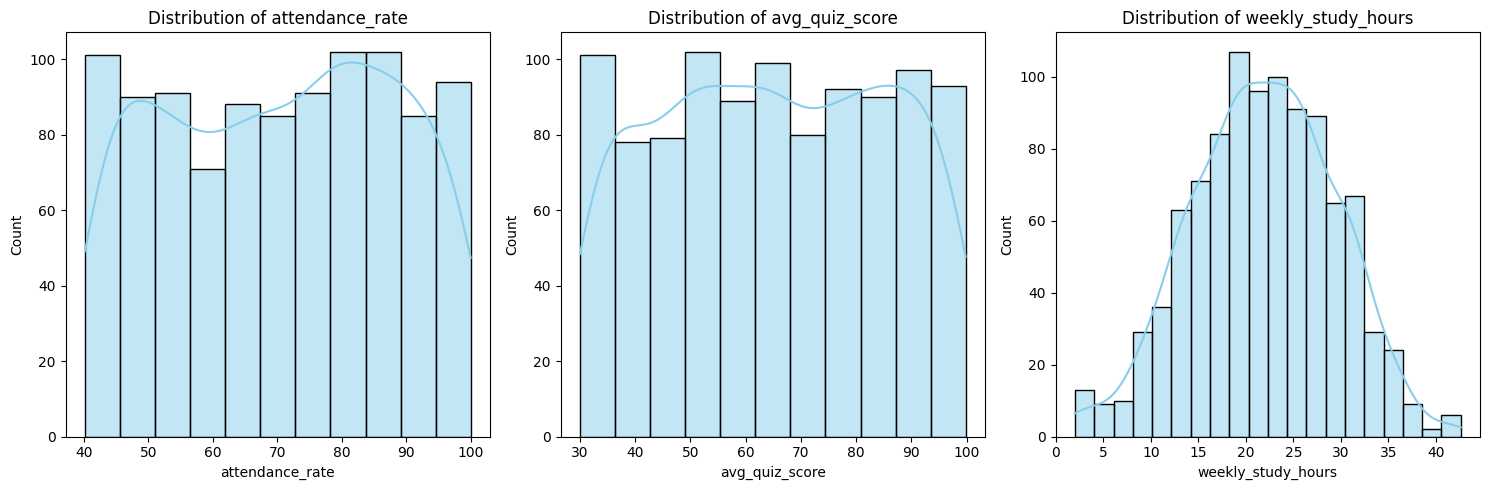

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize distributions of key features
plt.figure(figsize=(15, 5))
for i, col in enumerate(['attendance_rate', 'avg_quiz_score', 'weekly_study_hours']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### 2. Корреляционная матрица

Далее давайте посмотрим на взаимосвязи между всеми признаками с помощью корреляционной матрицы.

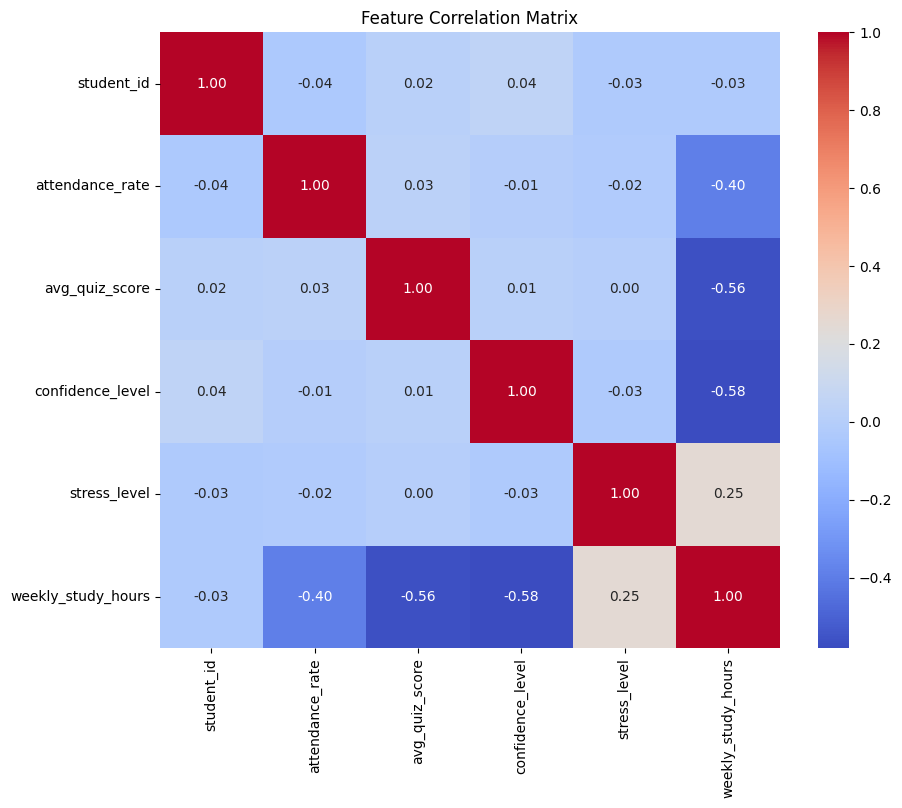

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Finalize data splitting for reproducibility
X = df_ml_ready.drop('weekly_study_hours', axis=1)
y = df_ml_ready['weekly_study_hours']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"✅ Data split: {len(X_train)} training samples, {len(X_test)} testing samples.")

✅ Data split: 800 training samples, 200 testing samples.


### Training the Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import joblib
import os
import pandas as pd

# Split and Train
X = df_ml_ready.drop('weekly_study_hours', axis=1)
y = df_ml_ready['weekly_study_hours']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

os.makedirs('ml', exist_ok=True)
model_filepath = os.path.join('ml', 'linear_regression_model.joblib')
joblib.dump(model, model_filepath)

print("✅ Linear Regression model trained and saved.")
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
display(coefficients.sort_values(by='Coefficient', ascending=False))

✅ Linear Regression model trained and saved.


,Feature,Coefficient
3,stress_level,1.256066
5,gender_Male,0.077806
4,gender_Female,-0.077806
0,attendance_rate,-0.160687
1,avg_quiz_score,-0.204015
2,confidence_level,-1.473978


### Evaluating Model Performance

--- Model Performance Metrics ---
Mean Absolute Error: 2.39 hours
Mean Squared Error: 8.62
R-squared Score: 0.85


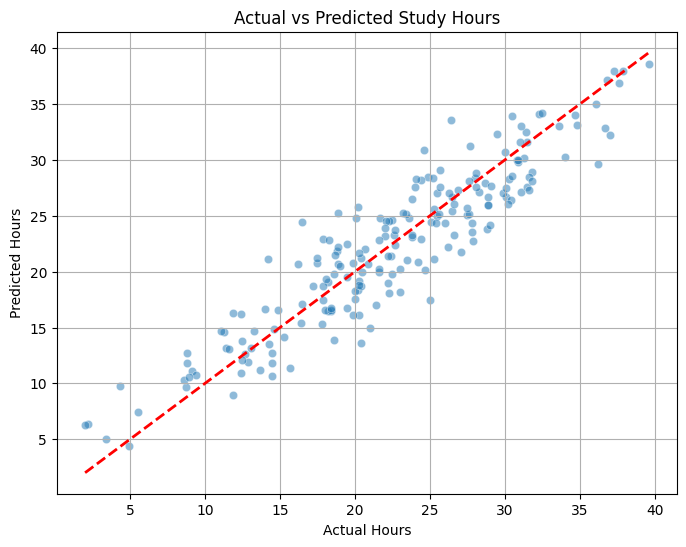

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions and evaluation
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Performance Metrics ---")
print(f"Mean Absolute Error: {mae:.2f} hours")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Hours')
plt.ylabel('Predicted Hours')
plt.title('Actual vs Predicted Study Hours')
plt.grid(True)
plt.show()

# 🖥️ SECTION 3: INTERACTIVE USER INTERFACE & INTEGRATION
This final section integrates the ML, Rules, and Search components into a unified interface for real-time student success monitoring.

In [ ]:
def collect_inputs():
    profile = {
        "name": "", "gender": "", "stress_level": 0, "confidence_level": 0,
        "attendance_rate": 0, "avg_quiz_score": 0, "missed_sessions": 0,
        "free_hours": 0, "task_difficulty": "medium", "deadline_days": 5,
        "tasks": [], "busy_blocks": [], "risk_signal": 0,
        "predicted_hours": 0.0, "schedule": [], "risk_level": "", "explanations": [],
        "priority": "NORMAL", "overload_flag": False
    }

    print("--- Student Profile ---")
    profile["name"] = input("What is your name? ")
    profile["gender"] = input("What is your gender? (Male/Female) ")

    def safe_int(prompt, default=0):
        while True:
            res = input(prompt)
            if not res.strip(): return default
            try: return int(res)
            except ValueError: print("Please enter a number (e.g., 5).")

    profile["attendance_rate"] = safe_int("What is your attendance rate (0-100)? ")
    profile["avg_quiz_score"] = safe_int("What is your average quiz score (0-100)? ")
    profile["missed_sessions"] = safe_int("How many study sessions have you missed lately? ")
    profile["free_hours"] = safe_int("How many free hours do you have for studying this week? ")

    stress_input = input("On a scale of 1-5, how stressed do you feel? ")
    profile["stress_level"] = int(stress_input) if stress_input.isdigit() else 3

    conf_input = input("On a scale of 1-10, how confident are you with your subjects? ")
    profile["confidence_level"] = int(conf_input) if conf_input.isdigit() else 5

    num_tasks = safe_int("How many specific tasks are on your list for this week? ")
    for i in range(num_tasks):
        t_name = input(f"Task {i+1} name: ")
        t_hours = safe_int(f"Estimated hours for '{t_name}': ", 1)
        t_due = input(f"What day is '{t_name}' due? (e.g., Tuesday): ").capitalize()
        t_diff = input(f"Difficulty for '{t_name}' (easy/medium/hard): ").lower()
        profile["tasks"].append({"name": t_name, "hours": t_hours, "deadline": t_due, "difficulty": t_diff})
        if t_diff == "hard": profile["task_difficulty"] = "hard"

    # Smart Prompting Logic: Only ask if NOT already calculated/entered
    re_engine = RuleEngine()
    # Pre-fill engine with what we have
    re_engine.working_memory = {
        "stress_level": profile["stress_level"],
        "confidence_level": profile["confidence_level"],
        "attendance_rate": profile["attendance_rate"],
        "missed_sessions": profile["missed_sessions"],
        "total_task_hours": sum(t['hours'] for t in profile['tasks']),
        "free_hours": profile["free_hours"]
    }

    missing = re_engine.backward_chain("risk_level")
    better_labels = {
        "deadline_days": "In how many days is your earliest big deadline?",
        "risk_signal": "How would you rate your risk of failing this week (1-10)?",
        "priority": "Is this week a HIGH or NORMAL priority for you?"
    }

    if missing:
        print("\n--- Additional Context Needed ---")
        for m in missing:
            if m in profile and (profile[m] == 0 or profile[m] == "" or profile[m] == "NORMAL"):
                if m in better_labels:
                    val = input(f"{better_labels[m]} ")
                    profile[m] = int(val) if val.isdigit() else val.upper()

    return profile

In [ ]:
import joblib, numpy as np, pandas as pd, os
from sklearn.linear_model import LinearRegression

def run_system(student_profile):
    model_path = 'ml/linear_regression_model.joblib'
    re = RuleEngine()
    facts = student_profile.copy()
    facts["total_task_hours"] = sum(t['hours'] for t in student_profile['tasks'])
    facts["task_difficulty"] = student_profile['tasks'][0]['difficulty'] if student_profile['tasks'] else "medium"
    facts["deadline_days"] = student_profile.get("deadline_days", 5)
    facts["missed_sessions"] = student_profile.get("missed_sessions", 0)
    results = re.forward_chain(facts)
    student_profile["risk_level"] = results['risk_level']
    student_profile["explanations"] = [r['explanation'] for r in results['fired_rules']]
    model = joblib.load(model_path)
    feat = np.array([[student_profile['attendance_rate'], student_profile['avg_quiz_score'], student_profile['confidence_level'], student_profile['stress_level'], 1 if student_profile['gender'] == 'Female' else 0, 1 if student_profile['gender'] == 'Male' else 0]])
    student_profile["predicted_hours"] = round(model.predict(feat)[0], 1)

    planner = StudentPlanner(student_profile["name"])
    for t in student_profile["tasks"]: planner.add_task(t['name'], 1, t['hours'], t['deadline'])

    # 1. Initial Attempt: Greedy then A* with breaks
    sched, stats = planner.run_greedy()
    if float(stats['Completion'].strip('%')) < 100:
        sched, stats = planner.run_astar()

    # 2. Force Mode Attempt: If still incomplete, remove breaks and try A*
    if float(stats['Completion'].strip('%')) < 100:
        print("\n[!] Standard planning failed. Retrying in FORCE MODE (removing breaks) with A* Search...")
        planner.force_mode = True
        sched, stats = planner.run_astar()

    # 3. Final Fallback: If A* Force Mode fails, use Greedy Force Mode to show partial progress
    if float(stats['Completion'].strip('%')) < 100:
        print("[!] A* Force Mode incomplete. Falling back to Greedy Force Mode for best effort...")
        sched, stats = planner.run_greedy()

    student_profile['schedule'] = sched
    print("\n╔" + "═"*40 + "╗")
    print(f"   REPORT FOR: {student_profile['name']}")
    print("╚" + "═"*40 + "╝")
    print(f"RISK: {student_profile['risk_level'].upper()} | PREDICTED: {student_profile['predicted_hours']}h")

    # RESTORED: Reasons for risk assessment
    if student_profile["explanations"]:
        print("REASONS:")
        for exp in student_profile["explanations"]: print(f" • {exp}")

    if float(stats['Completion'].strip('%')) < 100:
        print("\n⚠️ WARNING: Impossible workload. Even without breaks, some deadlines will be missed.")

    print(f"Plan Completion: {stats['Completion']}")
    if sched: display(pd.DataFrame(sched)[['day', 'hour_label', 'task']])

In [ ]:
# This cell is now redundant as saving is handled in the training cell.
print("Model saving is now handled in the training cell above.")

Model saving is now handled in the training cell above.


In [ ]:
# --- FINAL PROJECT PRESENTATION: INTERACTIVE MODE ---
# This cell executes the complete Student Success Copilot system.
print("=== STUDENT SUCCESS COPILOT v1.0 ===")
user_profile = collect_inputs()
run_system(user_profile)

=== STUDENT SUCCESS COPILOT v1.0 ===
--- Student Profile ---
What is your name? Makhmudja
What is your gender? (Male/Female) male
What is your attendance rate (0-100)? 80
What is your average quiz score (0-100)? 56
How many study sessions have you missed lately? 3
How many free hours do you have for studying this week? 40
On a scale of 1-5, how stressed do you feel? 5
On a scale of 1-10, how confident are you with your subjects? 5
How many specific tasks are on your list for this week? 2
Task 1 name: cw
Estimated hours for 'cw': 20
What day is 'cw' due? (e.g., Tuesday): in three days
Difficulty for 'cw' (easy/medium/hard): hard
Task 2 name: cw2
Estimated hours for 'cw2': 10
What day is 'cw2' due? (e.g., Tuesday): in five days
Difficulty for 'cw2' (easy/medium/hard): hard

--- Additional Context Needed ---
Is this week a HIGH or NORMAL priority for you? high
How would you rate your risk of failing this week (1-10)? 4

╔════════════════════════════════════════╗
   REPORT FOR: Makhmudja
╚

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,day,hour_label,task
0,Tuesday,08:00 - 09:00,cw2
1,Tuesday,09:00 - 10:00,cw
2,Tuesday,10:00 - 11:00,BREAK
3,Tuesday,11:00 - 12:00,cw
4,Tuesday,12:00 - 13:00,cw
5,Tuesday,13:00 - 14:00,BREAK
6,Tuesday,14:00 - 15:00,cw
7,Tuesday,15:00 - 16:00,cw
8,Tuesday,16:00 - 17:00,BREAK
9,Tuesday,17:00 - 18:00,cw
